In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, zscore
import plotly.express as px
from sklearn.linear_model import LinearRegression


### EDA 1


✅ Data Loaded Successfully!
   Unnamed: 0  latitude  longitude     depth       mag magType       rms  \
0           0    41.758     23.249 -0.430517  3.296720      mw  0.255959   
1           1    41.802     23.108 -0.430517  2.920854      mw  0.227615   
2           2    52.763    160.277 -0.291162  4.716657      mw  0.360656   
3           3    51.424    161.638 -0.430517  4.299028      mw  0.331543   
4           4    30.684    100.608 -0.430517  3.442890      mw  0.266982   

         type    status  Year  ...  Day  Hour  Minute  Second  DayOfWeek  \
0  earthquake  reviewed  1904  ...    4    10      26       0          0   
1  earthquake  reviewed  1904  ...    4    10       2      34          0   
2  earthquake  reviewed  1904  ...   25    21       0      38          5   
3  earthquake  reviewed  1904  ...   25    14      45      39          5   
4  earthquake  reviewed  1904  ...   30    11      43      20          1   

     Mw  damage_potential  urbanity_indicator  risk_score 

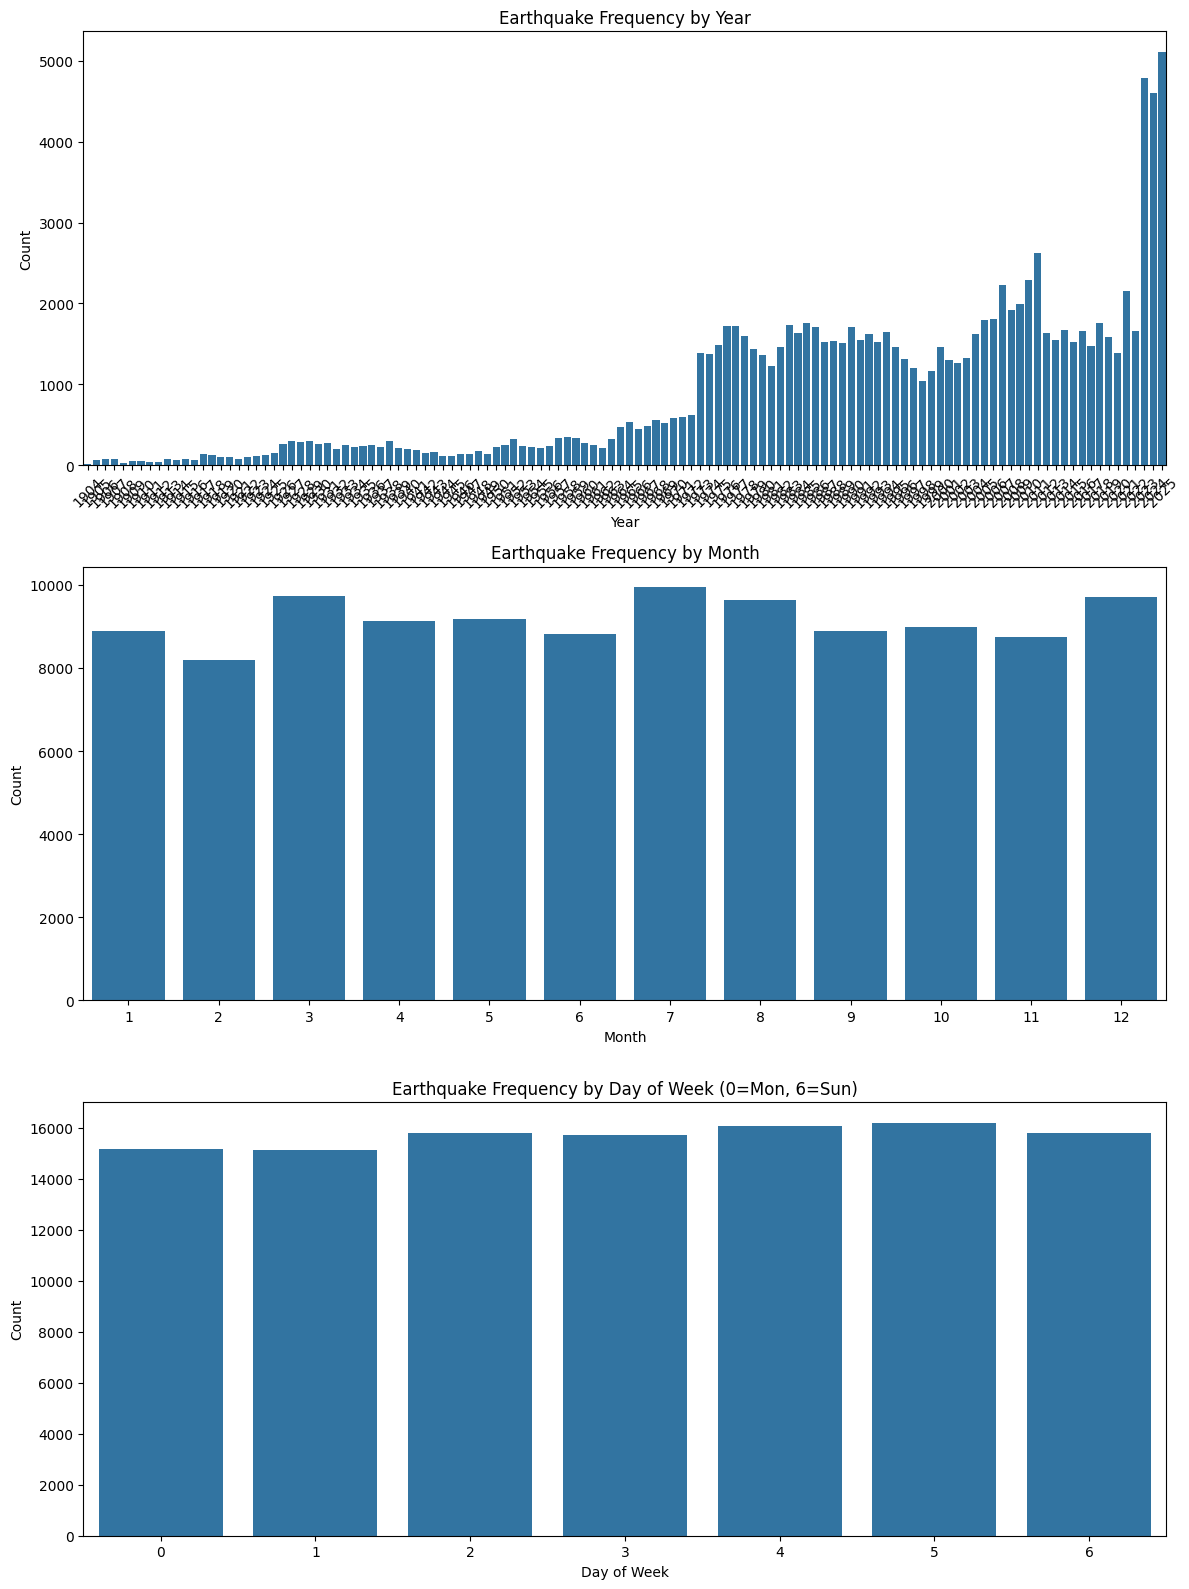

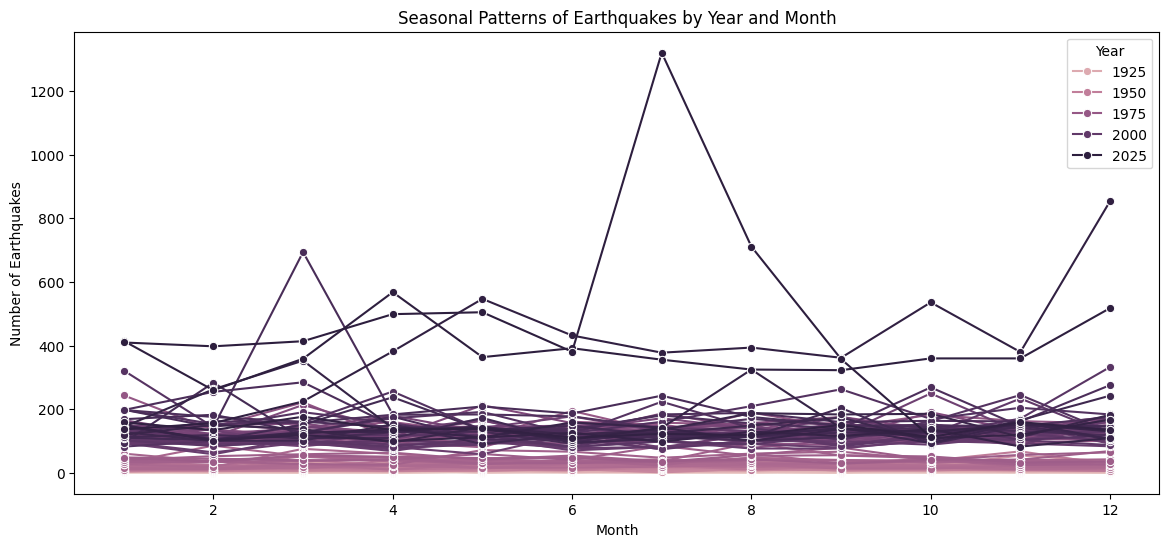

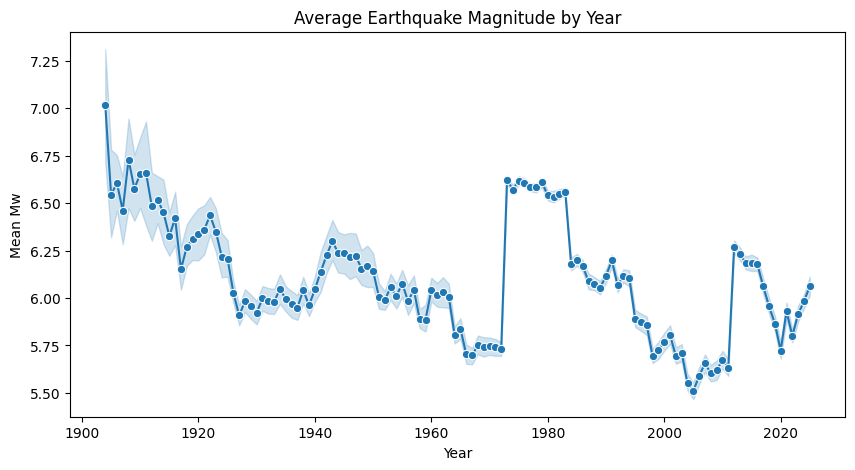

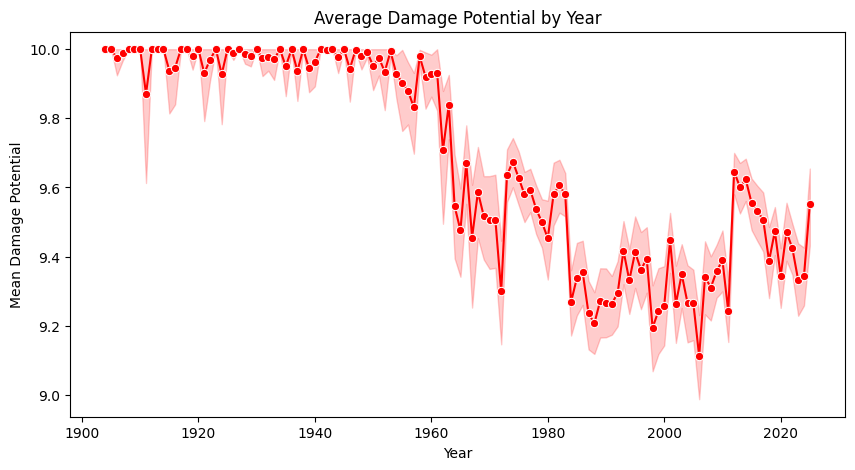

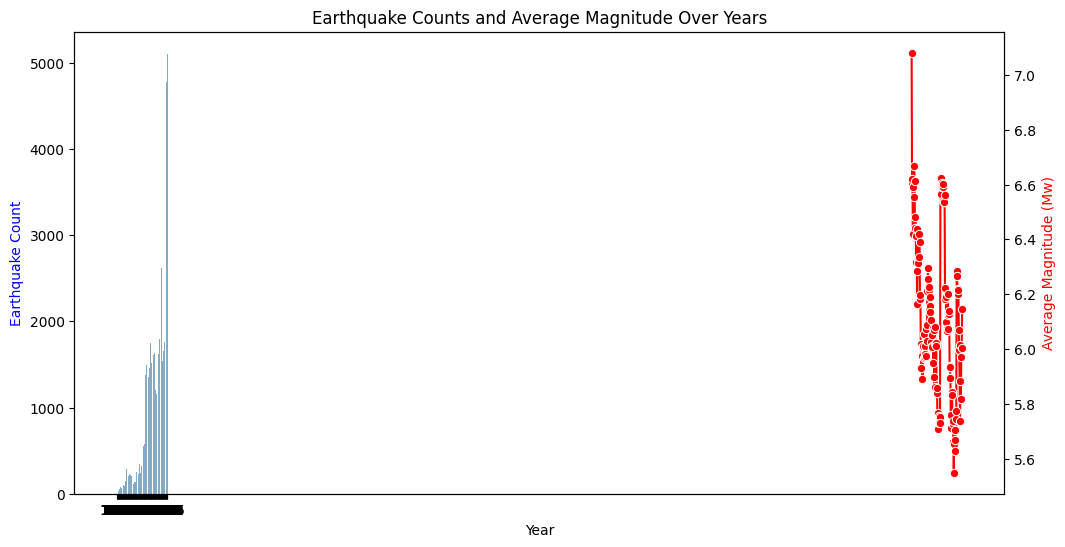

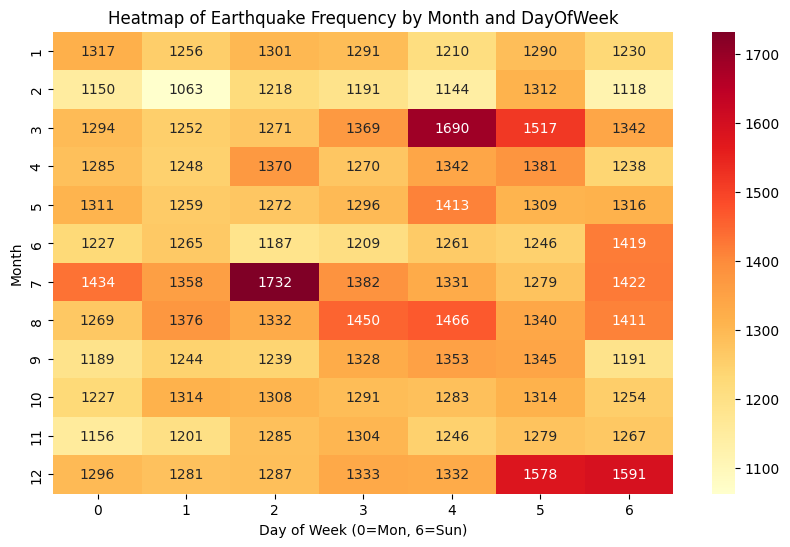

In [ ]:
# ============================================================
# 📊 EARTHQUAKE TEMPORAL ANALYSIS
# ============================================================


df = pd.read_csv("C:\\Users\\Dhruv\\Desktop\\Infosys_internship\\impactsenseAI-Infosys-Intern-project\\data\\preprocessed_earthquake_data_v4.csv")


# ------------------------------------------------------------
# ✅ Load your dataset (use raw string for Windows path)
# ------------------------------------------------------------
file_path = r"C:\\Users\\Dhruv\\Desktop\\Infosys_internship\\impactsenseAI-Infosys-Intern-project\\data\\preprocessed_earthquake_data_v4.csv"

# Check if file exists
if not os.path.exists(file_path):
    raise FileNotFoundError(f"File not found at: {file_path}")

df = pd.read_csv(file_path)

print("✅ Data Loaded Successfully!")
print(df.head())
print(f"Total Rows: {len(df)}\n")

# ------------------------------------------------------------
# 🧠 Verify essential columns exist
# ------------------------------------------------------------
required_cols = ['Year', 'Month', 'DayOfWeek', 'Mw', 'damage_potential']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")

# ------------------------------------------------------------
# 1️⃣ Earthquake Frequency by Year, Month, and DayOfWeek
# ------------------------------------------------------------

fig, axes = plt.subplots(3, 1, figsize=(12, 16))

# Frequency by Year
sns.countplot(x='Year', data=df, ax=axes[0])
axes[0].set_title('Earthquake Frequency by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Frequency by Month
sns.countplot(x='Month', data=df, ax=axes[1])
axes[1].set_title('Earthquake Frequency by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')

# Frequency by Day of Week
sns.countplot(x='DayOfWeek', data=df, ax=axes[2])
axes[2].set_title('Earthquake Frequency by Day of Week (0=Mon, 6=Sun)')
axes[2].set_xlabel('Day of Week')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 2️⃣ Identify Seasonal Patterns and Temporal Trends
# ------------------------------------------------------------
seasonal_trends = df.groupby(['Year', 'Month']).size().reset_index(name='Frequency')

plt.figure(figsize=(14,6))
sns.lineplot(x='Month', y='Frequency', hue='Year', data=seasonal_trends, marker='o')
plt.title('Seasonal Patterns of Earthquakes by Year and Month')
plt.xlabel('Month')
plt.ylabel('Number of Earthquakes')
plt.show()

# ------------------------------------------------------------
# 3️⃣ Mean Magnitude and Damage Potential by Temporal Dimensions
# ------------------------------------------------------------
mean_trends = df.groupby(['Year', 'Month', 'DayOfWeek'])[['Mw', 'damage_potential']].mean().reset_index()

# Mean Magnitude by Year
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='Mw', data=mean_trends, marker='o')
plt.title('Average Earthquake Magnitude by Year')
plt.xlabel('Year')
plt.ylabel('Mean Mw')
plt.show()

# Mean Damage Potential by Year
plt.figure(figsize=(10,5))
sns.lineplot(x='Year', y='damage_potential', data=mean_trends, marker='o', color='red')
plt.title('Average Damage Potential by Year')
plt.xlabel('Year')
plt.ylabel('Mean Damage Potential')
plt.show()

# ------------------------------------------------------------
# 4️⃣ Time Series: Earthquake Counts and Average Magnitude over Years
# ------------------------------------------------------------
yearly_summary = df.groupby('Year').agg(
    earthquake_count=('Mw', 'count'),
    avg_magnitude=('Mw', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(12,6))

# Count on left axis
sns.barplot(x='Year', y='earthquake_count', data=yearly_summary, ax=ax1, alpha=0.6)
ax1.set_ylabel('Earthquake Count', color='blue')
ax1.set_xlabel('Year')

# Add avg magnitude on right axis
ax2 = ax1.twinx()
sns.lineplot(x='Year', y='avg_magnitude', data=yearly_summary, ax=ax2, color='red', marker='o')
ax2.set_ylabel('Average Magnitude (Mw)', color='red')

plt.title('Earthquake Counts and Average Magnitude Over Years')
plt.show()

# ------------------------------------------------------------
# 5️⃣ Heatmap of Earthquakes by Month and DayOfWeek
# ------------------------------------------------------------
heatmap_data = df.groupby(['Month', 'DayOfWeek']).size().unstack(fill_value=0)

plt.figure(figsize=(10,6))
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Heatmap of Earthquake Frequency by Month and DayOfWeek')
plt.xlabel('Day of Week (0=Mon, 6=Sun)')
plt.ylabel('Month')
plt.show()


### EDA2

In [ ]:

# ------------------------------------------------------------
# 🧠 Basic verification
# ------------------------------------------------------------
required_cols = ['latitude', 'longitude', 'Mw', 'damage_potential']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

print("\nData Summary:")
print(df[required_cols].describe())

# ============================================================
# 1️⃣ Scatter Plot: Latitude vs Longitude colored by magnitude
# ============================================================

plt.figure(figsize=(10,8))
sns.scatterplot(
    x='longitude', 
    y='latitude', 
    data=df, 
    hue='Mw', 
    palette='coolwarm', 
    alpha=0.7, 
    edgecolor=None
)
plt.title("Earthquake Epicenters Colored by Magnitude (Mw)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Magnitude", loc="upper right")
plt.show()

# ============================================================
# 2️⃣ Scatter Plot: Colored by Damage Potential
# ============================================================

plt.figure(figsize=(10,8))
sns.scatterplot(
    x='longitude', 
    y='latitude', 
    data=df, 
    hue='damage_potential', 
    palette='YlOrRd', 
    alpha=0.7
)
plt.title("Earthquake Epicenters Colored by Damage Potential")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(title="Damage Potential", loc="upper right")
plt.show()

# ============================================================
# 3️⃣ Density Map (2D Histogram / Heatmap)
# ============================================================

plt.figure(figsize=(10,8))
plt.hist2d(
    df['longitude'], 
    df['latitude'], 
    bins=(50,50), 
    cmap='hot', 
    alpha=0.8
)
plt.colorbar(label='Earthquake Frequency')
plt.title("2D Density Map of Earthquake Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

# ============================================================
# 4️⃣ Geographical Binning (Regional Analysis)
# ============================================================

# Define bins for regions (e.g., 10° bins)
lat_bins = np.arange(df['latitude'].min(), df['latitude'].max(), 10)
lon_bins = np.arange(df['longitude'].min(), df['longitude'].max(), 10)

df['lat_region'] = pd.cut(df['latitude'], bins=lat_bins)
df['lon_region'] = pd.cut(df['longitude'], bins=lon_bins)

# Group by regions and calculate summary stats
region_summary = df.groupby(['lat_region', 'lon_region']).agg(
    count=('Mw', 'count'),
    avg_magnitude=('Mw', 'mean'),
    avg_damage=('damage_potential', 'mean')
).reset_index()

print("\nRegional Summary Statistics:")
print(region_summary.head(10))

# Top 10 most active regions
top_regions = region_summary.sort_values(by='count', ascending=False).head(10)
print("\nTop 10 Most Active Regions (by Frequency):")
print(top_regions[['lat_region', 'lon_region', 'count', 'avg_magnitude', 'avg_damage']])

# ============================================================
# 5️⃣ Correlation between Geography and Seismic Characteristics
# ============================================================

corr_data = df[['latitude', 'longitude', 'Mw', 'damage_potential']].corr()
print("\nCorrelation Matrix:")
print(corr_data)

plt.figure(figsize=(6,4))
sns.heatmap(corr_data, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation between Geographical Coordinates and Seismic Features")
plt.show()

# ============================================================
# 6️⃣ Identify High-Risk Geographical Areas
# ============================================================
# ------------------------------------------------------------
# Ensure required columns exist
# ------------------------------------------------------------
required_cols = ['latitude', 'longitude', 'Mw', 'damage_potential']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Missing required column: {col}")

# ------------------------------------------------------------
# Normalize magnitude or damage_potential for better color scaling
# ------------------------------------------------------------
df = df.dropna(subset=['latitude', 'longitude', 'Mw', 'damage_potential'])

# Now safely scale
df['scaled_mag'] = (df['Mw'] - df['Mw'].min()) / (df['Mw'].max() - df['Mw'].min())

# ------------------------------------------------------------
# Create Interactive Scatter Geo Map
# ------------------------------------------------------------
fig = px.scatter_geo(
    df,
    lat='latitude',
    lon='longitude',
    color='Mw',  # or use 'damage_potential'
    size='scaled_mag',  # size proportional to magnitude
    projection='natural earth',
    color_continuous_scale='Viridis',  # color theme
    opacity=0.6,
    hover_name='Mw',  # tooltip info
    hover_data={'damage_potential': True, 'latitude': True, 'longitude': True},
    title='Global Earthquake Epicenters (Magnitude Colored)',
    size_max=10
)

# ------------------------------------------------------------
# Display map
# ------------------------------------------------------------
fig.show(renderer='notebook')  

### Eda 3

Data loaded: (109848, 21)
After dropping missing damage_potential: (109848, 21)
                mag             Mw         depth  damage_potential
count  1.098480e+05  109715.000000  1.098480e+05     109848.000000
mean   3.974196e-16       6.057454 -9.314521e-17          9.499909
std    1.000005e+00       0.652358  1.000005e+00          1.440446
min   -9.213276e-01       5.000000 -6.070324e-01          0.000000
25%   -7.125134e-01       5.400000 -4.769683e-01         10.000000
50%   -2.948849e-01       6.130000 -2.632915e-01         10.000000
75%    3.942021e-01       6.617000 -9.606619e-02         10.000000
max    8.475313e+00       9.500000  5.933336e+00         10.000000


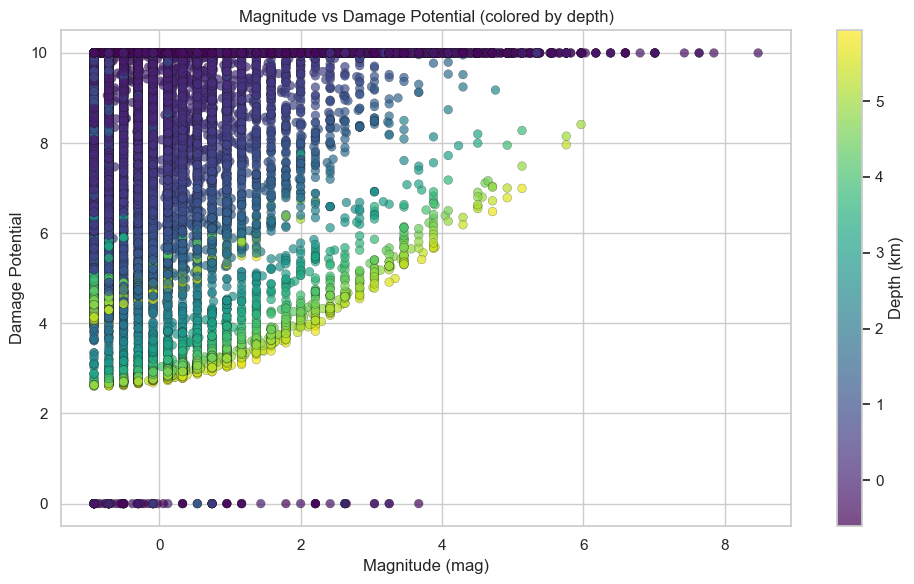

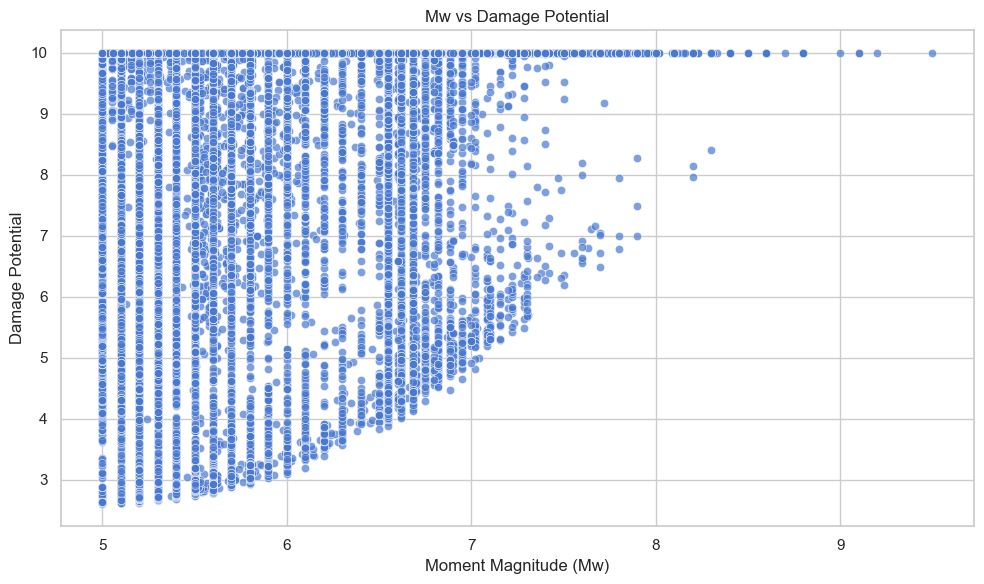

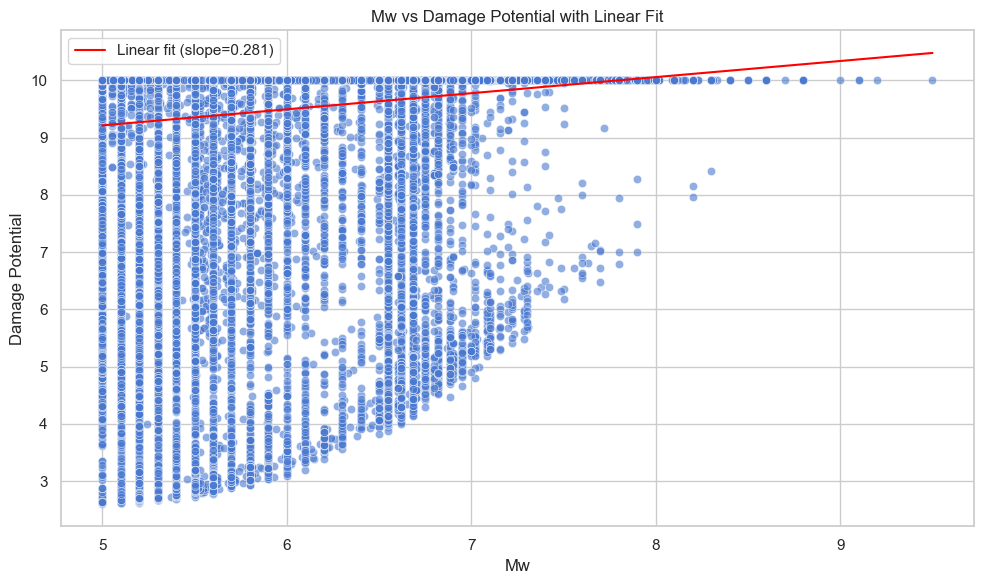

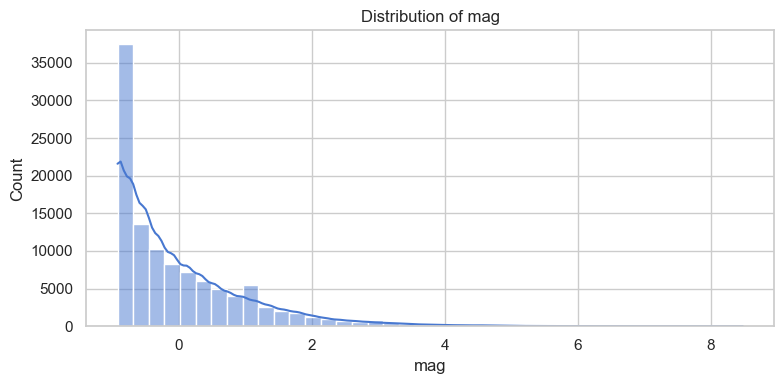

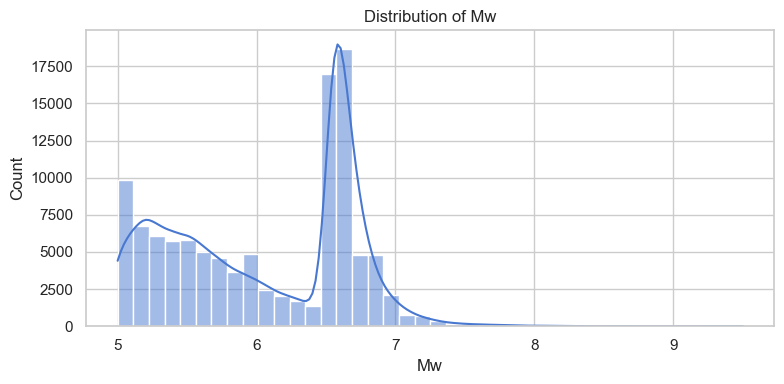

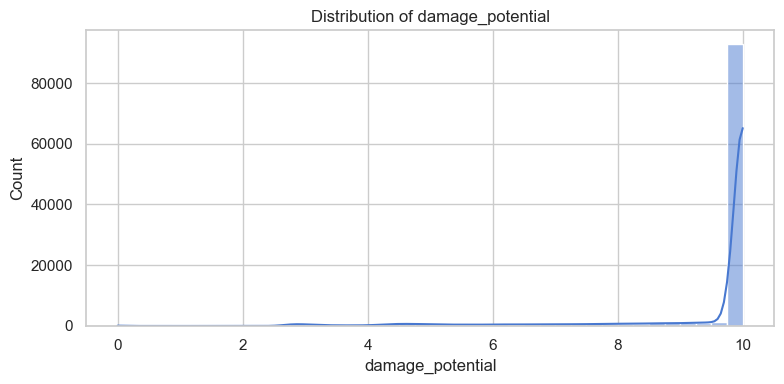


Correlation results:
mag vs damage_potential: Pearson r = 0.0315 (p=1.8e-25),  Spearman rho = 0.0465 (p=1.3e-53)
Mw vs damage_potential: Pearson r = 0.1308 (p=0),  Spearman rho = 0.1664 (p=0)


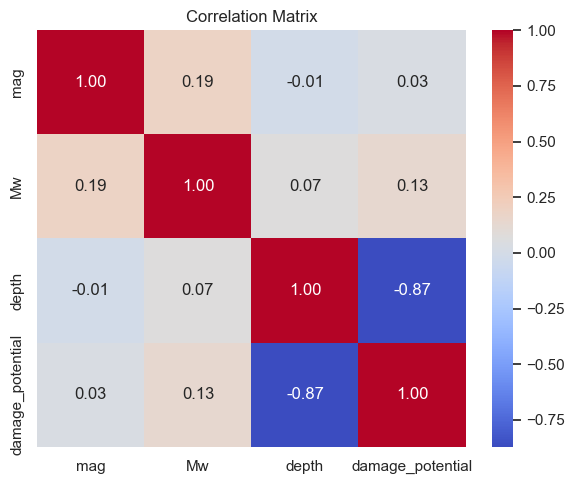


Top damage_potential threshold (99th percentile): 10.000
Top high damage potential rows (first 10):
      mag    Mw     depth  damage_potential  latitude  longitude
-0.921328 6.550 -0.371245              10.0  -16.3041   167.2480
 3.296720 7.020 -0.430517              10.0   41.7580    23.2490
 2.920854 6.840 -0.430517              10.0   41.8020    23.1080
 4.716657 7.700 -0.291162              10.0   52.7630   160.2770
 4.299028 7.500 -0.430517              10.0   51.4240   161.6380
-0.503699 6.684 -0.476968              10.0   51.9896  -169.7646
 1.166815 6.000  0.018539              10.0   -5.4364   153.7947
 4.925471 7.800 -0.388710              10.0   53.1928   160.5129
-0.503699 6.684 -0.345139              10.0   52.6880   160.8695
 0.122744 5.500 -0.291162              10.0   51.2024  -178.0199

Number of damage_potential z-score outliers (|z|>3): 4634
      mag    Mw    depth  damage_potential  latitude  longitude
-0.086071 5.400 1.367155          5.178586  -18.1840  -174.97

In [2]:
# EDA Task 3: Magnitude and Damage Potential Relationship
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, zscore
from sklearn.linear_model import LinearRegression

# Set plot style
sns.set(style="whitegrid", palette="muted")

# -----------------------------
# Load data (Windows path)
# -----------------------------
file_path = r"C:\Users\Dhruv\Desktop\Infosys_internship\impactsenseAI-Infosys-Intern-project\data\preprocessed_earthquake_data_v4.csv"
if not os.path.exists(file_path):
    raise FileNotFoundError(f"CSV not found: {file_path}")

df = pd.read_csv(file_path)
print("Data loaded:", df.shape)

# -----------------------------
# Basic cleaning / checks
# -----------------------------
# Required columns
req = ['mag', 'Mw', 'depth', 'damage_potential', 'latitude', 'longitude']
for c in req:
    if c not in df.columns:
        print(f"Warning: column '{c}' not found in dataset.")
        
# Drop rows missing the main columns we need
df = df.dropna(subset=['damage_potential']).copy()
df['mag'] = df['mag'].astype(float, errors='ignore')
df['Mw']  = df['Mw'].astype(float, errors='ignore')
df['depth']= pd.to_numeric(df['depth'], errors='coerce')
df[['mag', 'Mw', 'depth']] = df[['mag','Mw','depth']].apply(pd.to_numeric, errors='coerce')

print("After dropping missing damage_potential:", df.shape)
print(df[['mag','Mw','depth','damage_potential']].describe())

# -----------------------------
# 1) Scatter: mag vs damage_potential colored by depth
# -----------------------------
plt.figure(figsize=(10,6))
sc = plt.scatter(
    x=df['mag'], 
    y=df['damage_potential'],
    c=df['depth'],
    cmap='viridis',
    alpha=0.7,
    s=40,
    edgecolor='k',
    linewidth=0.2
)
plt.colorbar(sc, label='Depth (km)')
plt.xlabel('Magnitude (mag)')
plt.ylabel('Damage Potential')
plt.title('Magnitude vs Damage Potential (colored by depth)')
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Scatter: Mw vs damage_potential (Moment Magnitude)
# -----------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(x='Mw', y='damage_potential', data=df, alpha=0.7)
plt.xlabel('Moment Magnitude (Mw)')
plt.ylabel('Damage Potential')
plt.title('Mw vs Damage Potential')
plt.grid(True)
plt.tight_layout()
plt.show()

# Optionally add a trend line (linear fit) for Mw vs damage_potential
mask = df[['Mw','damage_potential']].dropna().index
if len(mask) > 10:
    X = df.loc[mask, 'Mw'].values.reshape(-1,1)
    y = df.loc[mask, 'damage_potential'].values
    lr = LinearRegression().fit(X,y)
    xs = np.linspace(np.nanmin(df['Mw']), np.nanmax(df['Mw']), 200)
    plt.figure(figsize=(10,6))
    sns.scatterplot(x='Mw', y='damage_potential', data=df, alpha=0.6)
    plt.plot(xs, lr.predict(xs.reshape(-1,1)), color='red', label=f'Linear fit (slope={lr.coef_[0]:.3f})')
    plt.xlabel('Mw')
    plt.ylabel('Damage Potential')
    plt.title('Mw vs Damage Potential with Linear Fit')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 3) Distribution histograms + KDE for mag, Mw, damage_potential
# -----------------------------
cols = ['mag','Mw','damage_potential']
for c in cols:
    if c in df.columns:
        plt.figure(figsize=(8,4))
        sns.histplot(df[c].dropna(), kde=True, bins=40)
        plt.title(f'Distribution of {c}')
        plt.xlabel(c)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# -----------------------------
# 4) Correlation coefficients: Pearson & Spearman
# -----------------------------
pairs = [('mag','damage_potential'), ('Mw','damage_potential')]
print("\nCorrelation results:")
for x,y in pairs:
    if x in df.columns and y in df.columns:
        tmp = df[[x,y]].dropna()
        if len(tmp) >= 5:
            p_pearson, p_pval = pearsonr(tmp[x], tmp[y])
            s_spearman, s_pval = spearmanr(tmp[x], tmp[y])
            print(f"{x} vs {y}: Pearson r = {p_pearson:.4f} (p={p_pval:.2g}),  Spearman rho = {s_spearman:.4f} (p={s_pval:.2g})")
        else:
            print(f"Not enough data for {x} vs {y}")

# Show correlation matrix
corr = df[['mag','Mw','depth','damage_potential']].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Outlier analysis
#    - Damage potential outliers: top 1% or using z-score / IQR
#    - Points where damage_potential is unexpectedly high relative to Mw (residuals)
# -----------------------------
# (a) top 1% damage_potential
thr = df['damage_potential'].quantile(0.99)
high_dp = df[df['damage_potential'] >= thr].sort_values('damage_potential', ascending=False)
print(f"\nTop damage_potential threshold (99th percentile): {thr:.3f}")
print("Top high damage potential rows (first 10):")
display_cols = ['mag','Mw','depth','damage_potential','latitude','longitude']
print(high_dp[display_cols].head(10).to_string(index=False))

# (b) z-score method
df['dp_z'] = zscore(df['damage_potential'].fillna(df['damage_potential'].mean()))
z_outliers = df[np.abs(df['dp_z']) > 3].sort_values('dp_z', ascending=False)
print(f"\nNumber of damage_potential z-score outliers (|z|>3): {len(z_outliers)}")
if len(z_outliers) > 0:
    print(z_outliers[display_cols].head(10).to_string(index=False))

# (c) residual-based outliers: damage_potential vs Mw linear model residuals
tmp = df[['Mw','damage_potential']].dropna()
if len(tmp) >= 10:
    lr2 = LinearRegression().fit(tmp[['Mw']], tmp['damage_potential'])
    preds = lr2.predict(tmp[['Mw']])
    resid = tmp['damage_potential'].values - preds
    tmp = tmp.assign(resid=resid)
    tmp['abs_resid'] = np.abs(tmp['resid'])
    top_resid = tmp.sort_values('abs_resid', ascending=False).head(10)
    print("\nTop 10 residual outliers (damage_potential much different than expected for Mw):")
    print(top_resid[['Mw','damage_potential','resid']].to_string(index=False))

    # Map these back to original df rows to show depth/coords
    # merge on nearest matching Mw and damage_potential
    outlier_idx = top_resid.index
    print("\nCharacteristics for residual outliers (attempt):")
    print(df.loc[outlier_idx, display_cols].to_string(index=False))
else:
    print("\nNot enough pairs to compute residual outliers.")

# -----------------------------
# Deliverables summary (print)
# -----------------------------
print("\nDeliverables produced:")
print("- Scatter: mag vs damage_potential colored by depth")
print("- Scatter: Mw vs damage_potential (with optional linear fit)")
print("- Histograms + KDE for mag, Mw, damage_potential")
print("- Pearson and Spearman correlation coefficients")
print("- Outlier tables (top 1% damage_potential, z-score outliers, residual outliers)")


### Eda 4



Depth Category Distribution:
Depth_Category
Shallow (0-70 km)    22877
Name: count, dtype: int64


C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3157345840.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depth_Category', y='Mw', data=df, palette='viridis')


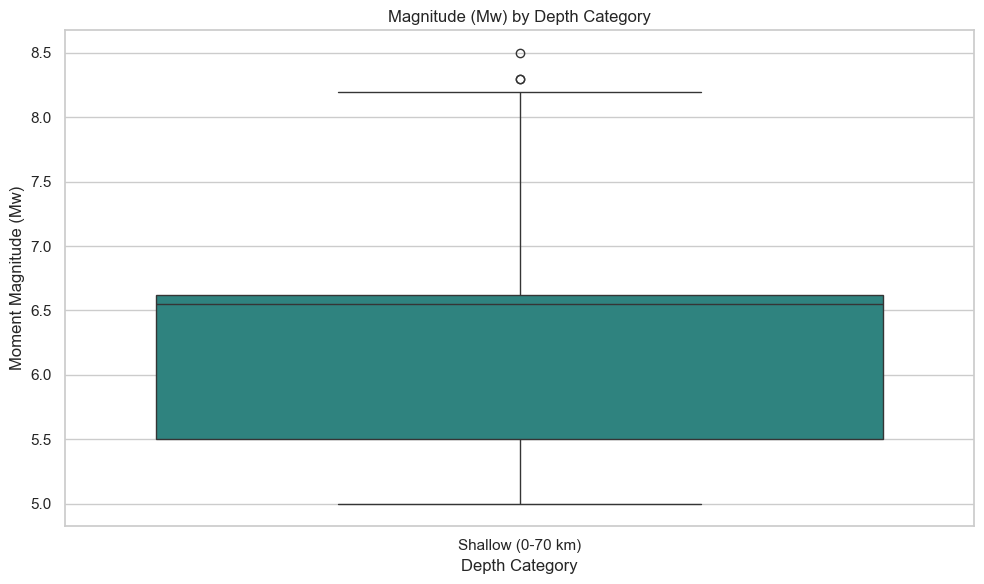

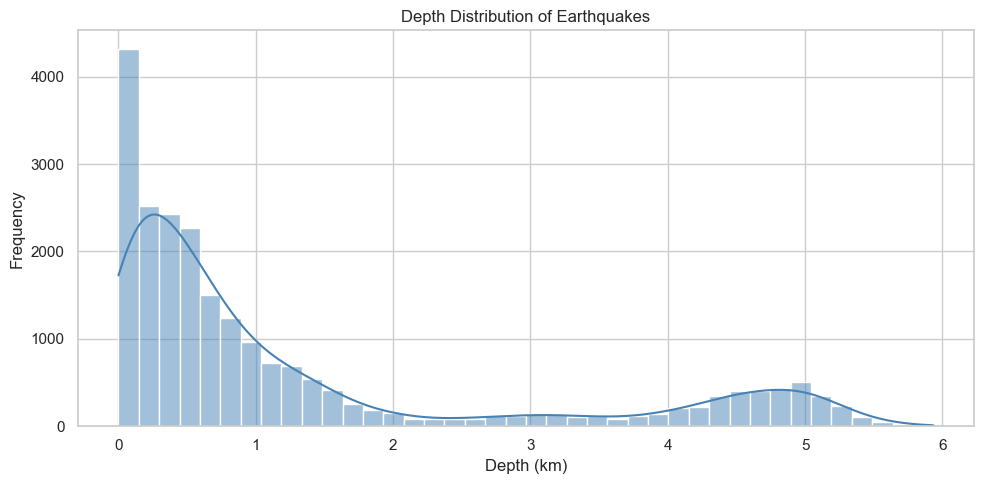


📊 Depth Summary Statistics:
count    22877.000000
mean         1.308661
std          1.603026
min          0.000126
25%          0.224449
50%          0.590487
75%          1.476558
max          5.933336


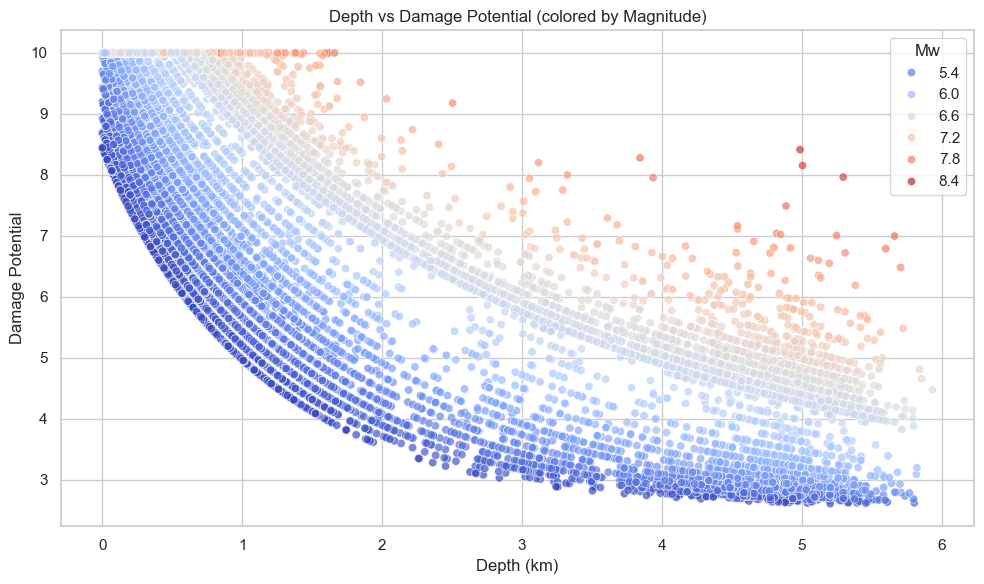

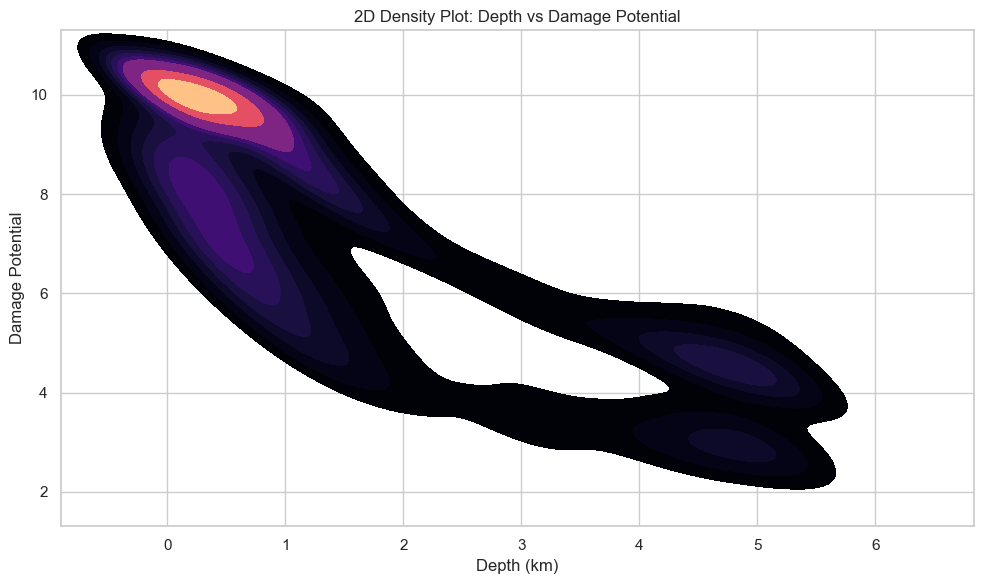


📋 Mean Damage Potential by Depth Category:
   Depth_Category  mean_depth  mean_magnitude  mean_damage  count
Shallow (0-70 km)    1.308661        6.125596     7.709246  22877

🔥 On average, **Shallow (0-70 km) earthquakes** cause the most damage.


C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3157345840.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Depth_Category', y='damage_potential', data=df, palette='YlOrRd', inner='quart')


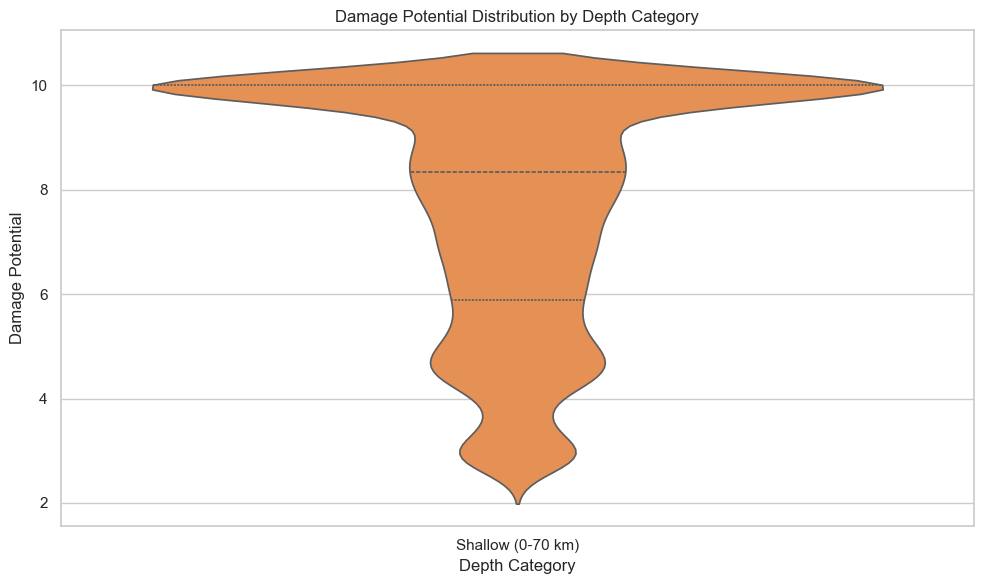

In [3]:
# ============================================================
# EDA Task 4: Depth Analysis and Its Impact
# ============================================================


# ------------------------------------------------------------
# Clean data and check essential columns
# ------------------------------------------------------------
required_cols = ['depth', 'Mw', 'damage_potential']
for col in required_cols:
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")

df = df.dropna(subset=required_cols)
df['depth'] = pd.to_numeric(df['depth'], errors='coerce')
df['Mw'] = pd.to_numeric(df['Mw'], errors='coerce')
df['damage_potential'] = pd.to_numeric(df['damage_potential'], errors='coerce')

# Remove negative or zero depths if any
df = df[df['depth'] > 0]

# ------------------------------------------------------------
# 1️⃣ Define depth categories (Shallow / Intermediate / Deep)
# ------------------------------------------------------------
def categorize_depth(d):
    if d <= 70:
        return 'Shallow (0-70 km)'
    elif d <= 300:
        return 'Intermediate (70-300 km)'
    else:
        return 'Deep (>300 km)'

df['Depth_Category'] = df['depth'].apply(categorize_depth)

print("\nDepth Category Distribution:")
print(df['Depth_Category'].value_counts())

# ------------------------------------------------------------
# 2️⃣ Box Plot: Depth Categories vs Magnitude
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.boxplot(x='Depth_Category', y='Mw', data=df, palette='viridis')
plt.title('Magnitude (Mw) by Depth Category')
plt.xlabel('Depth Category')
plt.ylabel('Moment Magnitude (Mw)')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 3️⃣ Histogram: Depth Distribution
# ------------------------------------------------------------
plt.figure(figsize=(10,5))
sns.histplot(df['depth'], bins=40, kde=True, color='steelblue')
plt.title('Depth Distribution of Earthquakes')
plt.xlabel('Depth (km)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n📊 Depth Summary Statistics:")
print(df['depth'].describe().to_string())

# ------------------------------------------------------------
# 4️⃣ Scatter Plot: Depth vs Damage Potential
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.scatterplot(x='depth', y='damage_potential', data=df, hue='Mw', palette='coolwarm', alpha=0.7)
plt.title('Depth vs Damage Potential (colored by Magnitude)')
plt.xlabel('Depth (km)')
plt.ylabel('Damage Potential')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5️⃣ 2D Density Plot (Depth vs Damage Potential)
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.kdeplot(
    data=df,
    x='depth',
    y='damage_potential',
    fill=True,
    cmap='magma',
    thresh=0.05
)
plt.title('2D Density Plot: Depth vs Damage Potential')
plt.xlabel('Depth (km)')
plt.ylabel('Damage Potential')
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6️⃣ Mean Damage Potential by Depth Category
# ------------------------------------------------------------
depth_summary = (
    df.groupby('Depth_Category')
    .agg(
        mean_depth=('depth', 'mean'),
        mean_magnitude=('Mw', 'mean'),
        mean_damage=('damage_potential', 'mean'),
        count=('depth', 'count')
    )
    .reset_index()
    .sort_values('mean_damage', ascending=False)
)

print("\n📋 Mean Damage Potential by Depth Category:")
print(depth_summary.to_string(index=False))

# ------------------------------------------------------------
# 7️⃣ Which causes more damage? Shallow vs Deep
# ------------------------------------------------------------
max_damage_cat = depth_summary.loc[depth_summary['mean_damage'].idxmax(), 'Depth_Category']
print(f"\n🔥 On average, **{max_damage_cat} earthquakes** cause the most damage.")

# ------------------------------------------------------------
# Optional: Violin Plot (shows distribution spread)
# ------------------------------------------------------------
plt.figure(figsize=(10,6))
sns.violinplot(x='Depth_Category', y='damage_potential', data=df, palette='YlOrRd', inner='quart')
plt.title('Damage Potential Distribution by Depth Category')
plt.xlabel('Depth Category')
plt.ylabel('Damage Potential')
plt.tight_layout()
plt.show()


### Eda 5

Remaining rows after cleanup: (22877, 23)

📊 Value Counts:

magType:
magType
mb     11402
mw      3637
mww     3549
mwc     3397
mwb      779
mwr       78
ms        18
ml        15
Ml         1
Mb         1
Name: count, dtype: int64

type:
type
earthquake    22877
Name: count, dtype: int64

status:
status
reviewed     22872
automatic        5
Name: count, dtype: int64


C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3053865105.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3053865105.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')
C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3053865105.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, palette='viridis')


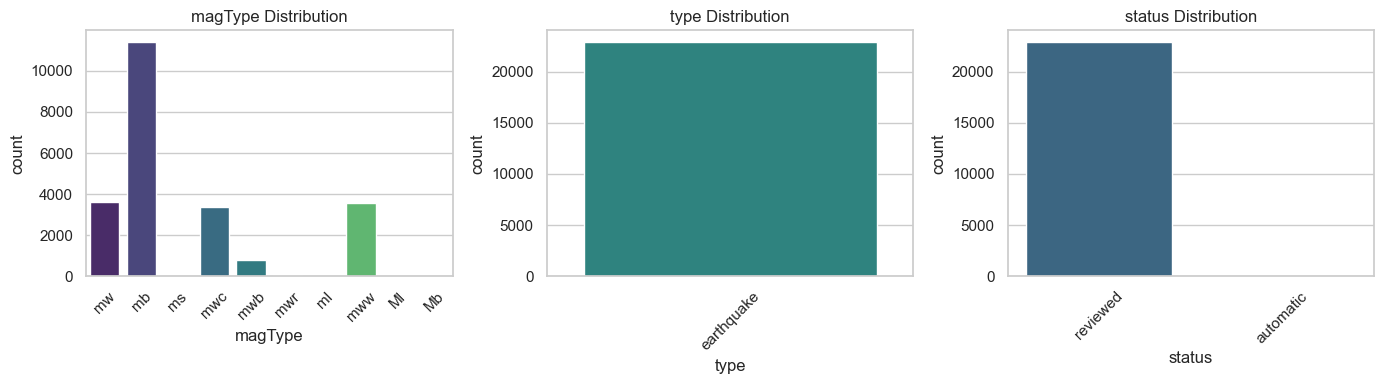


Grouped Summary by magType:
magType  mean_mag  mean_damage  count
     Mb -0.294885    10.000000      1
     Ml  0.749186     9.517442      1
     mb -0.550866     8.697099  11402
     ml  0.039218     7.276975     15
     ms  0.998603     8.778985     18
     mw  0.603728     7.011661   3637
    mwb  0.849439     7.088078    779
    mwc -0.092033     6.426130   3397
    mwr -0.747316     6.274395     78
    mww  0.271602     6.641704   3549


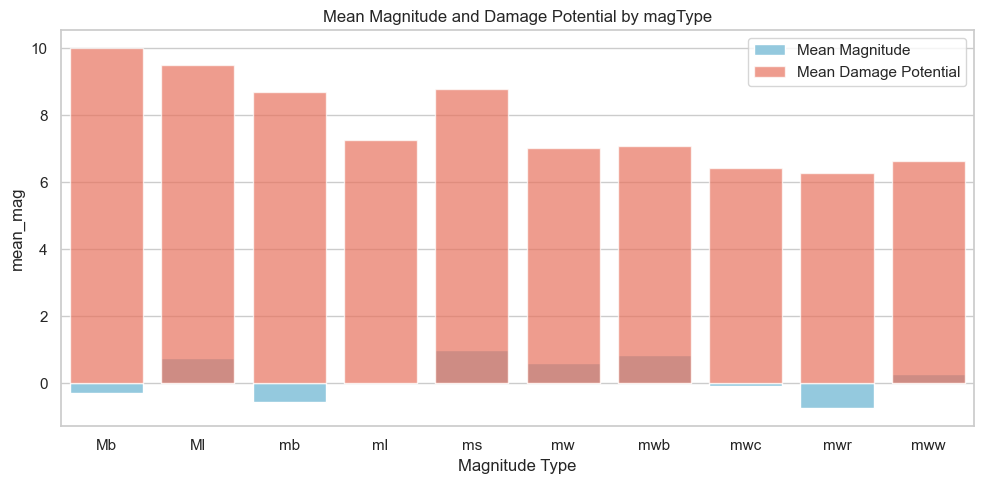


Contingency Table: Type vs Status
status      automatic  reviewed
type                           
earthquake          5     22872


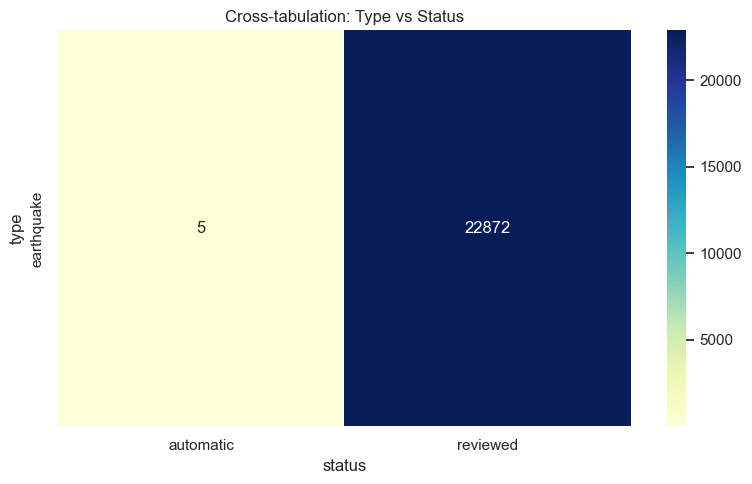

C:\Users\Dhruv\AppData\Local\Temp\ipykernel_20100\3053865105.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type', y='damage_potential', palette='coolwarm')


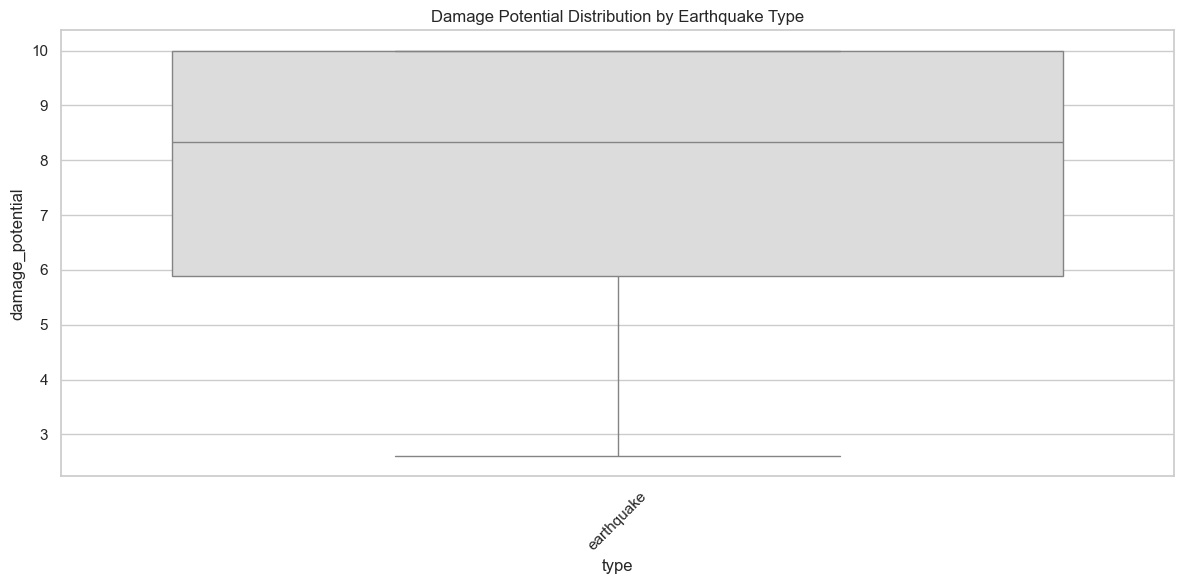

NameError: name 'chi2_contingency' is not defined

In [9]:
# ============================================================
# EDA Task 5: Categorical Feature Analysis
# ============================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import pingouin as pg   # for chi-square used in Cramér's V

sns.set(style="whitegrid", palette="muted")

# ------------------------------------------------------------
# Ensure categorical columns exist
# ------------------------------------------------------------
cat_cols = ['magType', 'type', 'status']
for c in cat_cols:
    if c not in df.columns:
        raise KeyError(f"Missing column: {c}")

df = df.dropna(subset=cat_cols + ['mag', 'damage_potential'])
print("Remaining rows after cleanup:", df.shape)

# ============================================================
# 1️⃣ Value counts for categorical variables
# ============================================================
print("\n📊 Value Counts:")
for col in cat_cols:
    print(f"\n{col}:\n{df[col].value_counts()}")

# ------------------------------------------------------------
# 2️⃣ Frequency Bar Charts
# ------------------------------------------------------------
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1,3,i)
    sns.countplot(x=col, data=df, palette='viridis')
    plt.title(f"{col} Distribution")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 3️⃣ Grouped bar chart: magType vs mean magnitude & damage_potential
# ============================================================
group_summary = df.groupby('magType').agg(
    mean_mag=('mag', 'mean'),
    mean_damage=('damage_potential', 'mean'),
    count=('mag', 'count')
).reset_index()

print("\nGrouped Summary by magType:")
print(group_summary.to_string(index=False))

plt.figure(figsize=(10,5))
sns.barplot(data=group_summary, x='magType', y='mean_mag', color='skyblue', label='Mean Magnitude')
sns.barplot(data=group_summary, x='magType', y='mean_damage', color='tomato', alpha=0.7, label='Mean Damage Potential')
plt.title('Mean Magnitude and Damage Potential by magType')
plt.xlabel('Magnitude Type')
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 4️⃣ Cross-tabulation (Contingency Tables)
# ============================================================
print("\nContingency Table: Type vs Status")
contingency = pd.crosstab(df['type'], df['status'])
print(contingency)

plt.figure(figsize=(8,5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cross-tabulation: Type vs Status')
plt.tight_layout()
plt.show()

# ============================================================
# 5️⃣ Boxplot: Type vs Damage Potential
# ============================================================
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='type', y='damage_potential', palette='coolwarm')
plt.title('Damage Potential Distribution by Earthquake Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 6️⃣ Cramér’s V: Association between categorical variables
# ============================================================
def cramers_v(confusion_matrix):
    """Compute Cramér's V statistic for categorical association."""
    chi2, p, dof, exp = chi2_contingency(confusion_matrix)
    n = confusion_matrix.values.sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Bias correction (recommended for small tables)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

cramer_results = {}
for a,b in itertools.combinations(cat_cols, 2):
    confusion = pd.crosstab(df[a], df[b])
    cramer_results[(a,b)] = cramers_v(confusion)

print("\n📈 Cramér’s V values (categorical associations):")
for (a,b), val in cramer_results.items():
    print(f"{a} vs {b}: {val:.3f}")

